In [3]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [5]:
path = r"C:\Users\Sakshi\Downloads\train\train"

In [4]:
import os

In [6]:
print(len(os.listdir(path)))

25000


In [8]:
import random

data = []
labels = []

# Get all files and shuffle them
files = os.listdir(path)
random.shuffle(files)

# Use only 500 images (mixed cats and dogs)
for img in files[:500]:
    
    # Label: cat = 0, dog = 1
    label = 0 if "cat" in img else 1
    
    img_path = os.path.join(path, img)
    
    # Read image in grayscale
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # Resize image
    image = cv2.resize(image, (64, 64))
    
    # Flatten image
    image = image.flatten()
    
    data.append(image)
    labels.append(label)

In [10]:
print(set(labels))

{0, 1}


In [11]:
X = np.array(data)
y = np.array(labels)

print(X.shape)
print(y.shape)

(500, 4096)
(500,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [14]:
y_pred = model.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.56


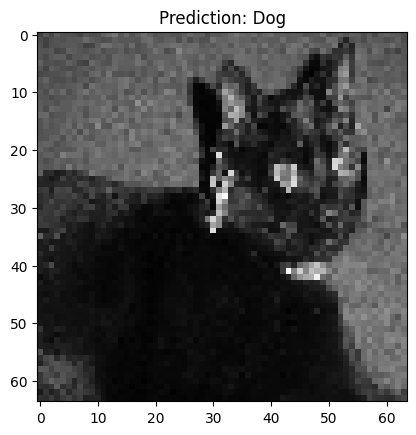

In [16]:
plt.imshow(X_test[0].reshape(64,64), cmap='gray')
plt.title("Prediction: " + ("Dog" if y_pred[0] == 1 else "Cat"))
plt.show()

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load your test image
img_path = "cat.jpg"   # change file name

image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
image = cv2.resize(image, (64,64))

# Flatten
image_flat = image.flatten().reshape(1, -1)

# Predict
prediction = model.predict(image_flat)

# Result
label = "Dog" if prediction[0] == 1 else "Cat"

plt.imshow(image, cmap='gray')
plt.title("Prediction: " + label)
plt.axis('off')
plt.show()

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'
